### 2 b) Impacto de la variación de $Z_c$ respecto a estados patológicos
En el modelo $WK_3$, la impedancia característica ($Z_c$) representa el estado físico de la raíz aórtica. Los cambios sistémicos afectan esta impedancia de entrada:
1. **Envejecimiento e Hipertensión:** Implican un aumento de la rigidez aórtica, lo que se traduce en una impedancia característica mayor ($Z_c \uparrow$). Esto provoca un empeoramiento en el acople de impedancias entre el ventrículo y la aorta.
2. **Shock Séptico:** La vasodilatación profunda relaja la pared aórtica, disminuyendo la impedancia característica ($Z_c \downarrow$).

A continuación, simularemos los tres escenarios comparando la curva con un $Z_c$ normal frente a la curva con el $Z_c$ alterado patológicamente.

### 2 b) Análisis completo: $WK_2$ vs $WK_3$ en estados patológicos
En este inciso analizaremos el impacto de la **Impedancia Característica ($Z_c$)** en los tres estados patológicos estudiados previamente.

Para cada enfermedad, compararemos tres escenarios:
1. El modelo **$WK_2$** (sin $Z_c$), donde la presión aórtica es "suavizada" totalmente por la compliance.
2. El modelo **$WK_3$** asumiendo una raíz aórtica sana ($Z_c$ normal).
3. El modelo **$WK_3$** con la raíz aórtica afectada por la patología ($Z_c$ patológico).

**Alteraciones esperadas de $Z_c$:**
* **Envejecimiento e Hipertensión:** La raíz aórtica se rigidiza, lo que incrementa el desajuste de impedancias ($Z_c \uparrow$).
* **Shock Séptico:** La vasodilatación profunda relaja los tejidos, reduciendo la impedancia de entrada ($Z_c \downarrow$).

In [2]:
# -------------------------------------------------------------------------
# MÓDULOS Y FUNCIÓN DE FLUJO
# -------------------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt

def Q_Sim(Qmax, T, t):
    Escala_ml = 1e5 * (Qmax / 8.8)
    Q = Escala_ml * ((7.9853e-06 + 2.6617e-05*np.sin(2*np.pi*t/T+0.29498) +
                      2.3616e-05*np.sin(4*np.pi*t/T-1.1403) - 1.9016e-05*np.sin(6*np.pi*t/T+0.40435) -
                      8.5899e-06*np.sin(8*np.pi*t/T-1.1892) - 2.436e-06*np.sin(10*np.pi*t/T-1.4918) +
                      1.4905e-06*np.sin(12*np.pi*t/T+1.0536) + 1.3581e-06*np.sin(14*np.pi*t/T-0.47666) -
                      6.3031e-07*np.sin(16*np.pi*t/T+0.93768) - 4.5335e-07*np.sin(18*np.pi*t/T-0.79472) -
                      4.5184e-07*np.sin(20*np.pi*t/T-1.4095) - 5.6583e-07*np.sin(22*np.pi*t/T-1.3629) +
                      4.9522e-07*np.sin(24*np.pi*t/T+0.52495) + 1.3049e-07*np.sin(26*np.pi*t/T-0.97261) -
                      4.1072e-08*np.sin(28*np.pi*t/T-0.15685) - 2.4182e-07*np.sin(30*np.pi*t/T-1.4052) -
                      6.6217e-08*np.sin(32*np.pi*t/T-1.3785) - 1.5511e-07*np.sin(34*np.pi*t/T-1.2927) +
                      2.2149e-07*np.sin(36*np.pi*t/T+0.68178) + 6.7621e-08*np.sin(38*np.pi*t/T-0.98825) +
                      1.0973e-07*np.sin(40*np.pi*t/T+1.4327) - 2.5559e-08*np.sin(42*np.pi*t/T-1.2372) -
                      3.5079e-08*np.sin(44*np.pi*t/T+0.2328)))
    return Q

In [3]:
# -------------------------------------------------------------------------
# FUNCIONES INTEGRADORAS: WK2 Y WK3 (Con presión inicial variable)
# -------------------------------------------------------------------------

def resolver_wk2_euler(Q, t, Ca, Rp, P0=80.0):
    dt = t[1] - t[0]
    P = np.zeros(len(t))
    P[0] = P0
    for i in range(1, len(t)):
        dP_dt = (Q[i-1] / Ca) - (P[i-1] / (Rp * Ca))
        P[i] = P[i-1] + (dP_dt * dt)
    return P

def resolver_wk3_euler(Q, t, Ca, Rp, Zc, P0=80.0):
    dt = t[1] - t[0]
    Pc = np.zeros(len(t))
    P_ao = np.zeros(len(t))

    Pc[0] = P0
    P_ao[0] = Pc[0] + (Q[0] * Zc)

    for i in range(1, len(t)):
        dP_dt = (Q[i-1] / Ca) - (Pc[i-1] / (Rp * Ca))
        Pc[i] = Pc[i-1] + (dP_dt * dt)
        P_ao[i] = Pc[i] + (Q[i] * Zc)

    return P_ao

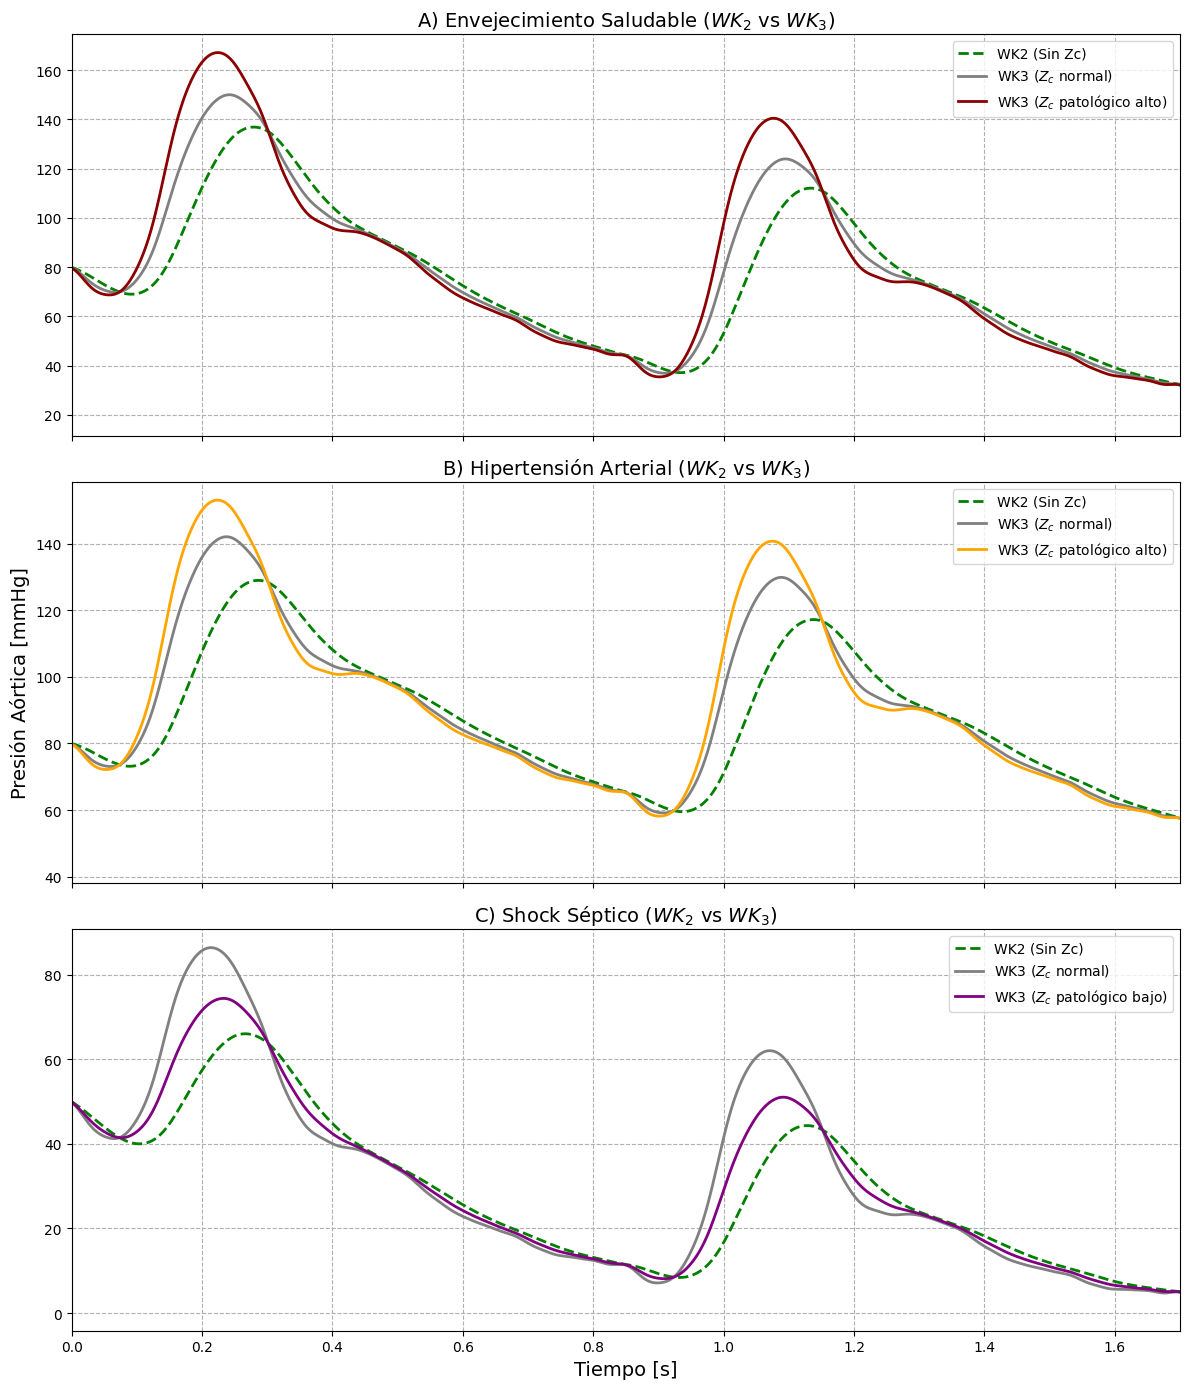

In [4]:
# -------------------------------------------------------------------------
# SIMULACIÓN 2b: COMPARATIVA WK2 vs WK3 EN LOS TRES ESTADOS
# -------------------------------------------------------------------------

# 1. Vectores de Tiempo y Flujo
Ts = 0.001
t = np.arange(0, 5, Ts)
Q_entrada = Q_Sim(Qmax=500, T=0.85, t=t)

# 2. Parámetros Basales Generales
Ca_basal = 1.1
Rp_basal = 0.9
Zc_normal = 0.06

# --- ESTADO 1: ENVEJECIMIENTO ---
Ca_env, Rp_env = Ca_basal * 0.60, Rp_basal * 1.30
Zc_env_alto = Zc_normal * 1.80  # Aumento por rigidez
P_env_wk2 = resolver_wk2_euler(Q_entrada, t, Ca_env, Rp_env)
P_env_wk3_norm = resolver_wk3_euler(Q_entrada, t, Ca_env, Rp_env, Zc_normal)
P_env_wk3_alt = resolver_wk3_euler(Q_entrada, t, Ca_env, Rp_env, Zc_env_alto)

# --- ESTADO 2: HIPERTENSIÓN ---
Ca_hta, Rp_hta = Ca_basal * 0.80, Rp_basal * 1.70
Zc_hta_alto = Zc_normal * 1.50  # Aumento por tensión de pared
P_hta_wk2 = resolver_wk2_euler(Q_entrada, t, Ca_hta, Rp_hta)
P_hta_wk3_norm = resolver_wk3_euler(Q_entrada, t, Ca_hta, Rp_hta, Zc_normal)
P_hta_wk3_alt = resolver_wk3_euler(Q_entrada, t, Ca_hta, Rp_hta, Zc_hta_alto)

# --- ESTADO 3: SHOCK SÉPTICO (Condición inicial baja P0=50) ---
Ca_sep, Rp_sep = Ca_basal * 1.20, Rp_basal * 0.40
Zc_sep_bajo = Zc_normal * 0.50  # Disminución por vasodilatación
P_sep_wk2 = resolver_wk2_euler(Q_entrada, t, Ca_sep, Rp_sep, P0=50.0)
P_sep_wk3_norm = resolver_wk3_euler(Q_entrada, t, Ca_sep, Rp_sep, Zc_normal, P0=50.0)
P_sep_wk3_bajo = resolver_wk3_euler(Q_entrada, t, Ca_sep, Rp_sep, Zc_sep_bajo, P0=50.0)

# -------------------------------------------------------------------------
# VISUALIZACIÓN EN TRES SUBPLOTS
# -------------------------------------------------------------------------
fig, axs = plt.subplots(3, 1, figsize=(12, 14), sharex=True)

# 1. Envejecimiento
axs[0].plot(t, P_env_wk2, '--', color='green', linewidth=2, label='WK2 (Sin Zc)')
axs[0].plot(t, P_env_wk3_norm, 'gray', linewidth=2, label='WK3 ($Z_c$ normal)')
axs[0].plot(t, P_env_wk3_alt, 'darkred', linewidth=2, label='WK3 ($Z_c$ patológico alto)')
axs[0].set_title('A) Envejecimiento Saludable ($WK_2$ vs $WK_3$)', fontsize=14)
axs[0].legend(loc='upper right')
axs[0].grid(True, linestyle='--')

# 2. Hipertensión
axs[1].plot(t, P_hta_wk2, '--', color='green', linewidth=2, label='WK2 (Sin Zc)')
axs[1].plot(t, P_hta_wk3_norm, 'gray', linewidth=2, label='WK3 ($Z_c$ normal)')
axs[1].plot(t, P_hta_wk3_alt, 'orange', linewidth=2, label='WK3 ($Z_c$ patológico alto)')
axs[1].set_title('B) Hipertensión Arterial ($WK_2$ vs $WK_3$)', fontsize=14)
axs[1].set_ylabel('Presión Aórtica [mmHg]', fontsize=14)
axs[1].legend(loc='upper right')
axs[1].grid(True, linestyle='--')

# 3. Shock Séptico
axs[2].plot(t, P_sep_wk2, '--', color='green', linewidth=2, label='WK2 (Sin Zc)')
axs[2].plot(t, P_sep_wk3_norm, 'gray', linewidth=2, label='WK3 ($Z_c$ normal)')
axs[2].plot(t, P_sep_wk3_bajo, 'purple', linewidth=2, label='WK3 ($Z_c$ patológico bajo)')
axs[2].set_title('C) Shock Séptico ($WK_2$ vs $WK_3$)', fontsize=14)
axs[2].set_xlabel('Tiempo [s]', fontsize=14)
axs[2].legend(loc='upper right')
axs[2].grid(True, linestyle='--')

# Ajustamos límites de X para observar los primeros dos latidos detalladamente
plt.xlim(0, 1.7)
plt.tight_layout()
plt.show()

### Conclusiones de la variación de $Z_c$
El término que domina los cambios rápidos en la señal es la caída de tensión instantánea $Q(t) \cdot Z_c$.

1. **Envejecimiento e Hipertensión:** Al aumentar $Z_c$, se produce una severa **desadaptación de impedancias** al inicio de la inyección ventricular. El flujo sanguíneo choca contra una pared muy rígida (alta impedancia), lo que genera que el pico sistólico se dispare bruscamente. Desde el punto de vista del trabajo cardíaco, esto obliga al ventrículo a consumir mucha más potencia instantánea para eyectar el mismo volumen.
2. **Shock Séptico:** Al disminuir $Z_c$ por la profunda vasodilatación, el sistema ofrece aún menos resistencia inicial a la onda de flujo. El acoplamiento es tan "suelto" que la onda pierde su pico agudo característico, y la presión sistólica máxima queda deprimida, agravando la hipotensión general.

### Conclusiones de la comparativa $WK_2$ vs $WK_3$

La superposición de ambos modelos permite ver claramente el "error" u omisión del $WK_2$:

1. **El defecto del $WK_2$:** En todos los gráficos, la curva del $WK_2$ (verde punteada) muestra un ascenso sistólico artificialmente suave. Toda la energía del flujo entrante es filtrada idealmente por el "capacitor" ($C_A$), ignorando la inercia y rigidez local del sitio donde se inyecta la sangre.

2. **La adición de $Z_c$ en patologías de alta presión:** Tanto en el envejecimiento como en la hipertensión, al incorporar el $WK_3$ con el $Z_c$ exacerbado por la rigidez vascular (curvas roja y naranja), observamos un "disparo" temprano en la sístole. Esta pendiente abrupta ($Q(t) \cdot Z_c$) explica los picos sistólicos agudos medidos clínicamente en pacientes ancianos e hipertensos, lo cual exige al corazón trabajar mucho más intensamente para vencer esa barrera inicial.

3. **La adición de $Z_c$ en la hipotensión (Shock):** En el shock séptico, la pared aórtica tan dilatada disminuye el valor de $Z_c$. La diferencia entre el $WK_3$ normal y el patológico nos muestra que esta "falla de tono vascular" amortigua en exceso el impulso inicial de la sangre (el pico púrpura es menor al pico gris), reflejando una pérdida de fuerza pulsátil que agrava el cuadro clínico.